<a href="https://colab.research.google.com/github/Yunuenn/EstadisticaInferencial2026A/blob/main/Problema%201%20y%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).

2.   Realice un diagrama de dispersión para estos datos.

3. ¿Los datos soportan la suposición de linealidad?

4. Calcule el coeficiente de correlación e interprete el resultado.

5. Calcule el coeficiente de determinación e interprete el resultado.

6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.

7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)

8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?

9. Realice la prueba de Shapiro para los residuales y comente el resultado.

10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.

11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?

12. Realice una tabla ANOVA e interprete el resultado.

In [53]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/Yunuenn/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"
df = pd.read_csv(link_csv)
df

,promedio_de_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


# **1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).**


```
# This is formatted as code
```



In [54]:
x = df ['promedio_de_examenes_cortos']
y = df['promedio_final']

# **2.   Realice un diagrama de dispersión para estos datos.**

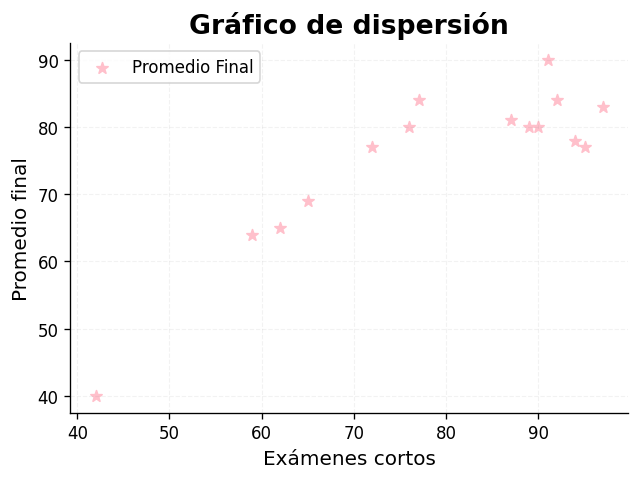

In [55]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="*",       # forma
    color='pink',     # color de los puntos
    edgecolor='pink',    # borde de los puntos
    alpha=1,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Promedio Final' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

# **3. ¿Los datos soportan la suposición de linealidad? No, ya que no muestran hasta ahora un orden específico.**

# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [56]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


**Interpretación del resultado: Según h0 si la correlación es igual a 0 no hay correlación, por lo tanto como el valor p=0 existe evidencia de correlación lineal significativa.**

In [57]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
promedio_de_examenes_cortos,0.643180


$$
\hat{y} = 24.526822+0.643180
$$

donde
- $\hat{y}$ es el promedio final calculado por el modelo
- $X$ es el promedio de exámenes cortos

# **5. Calcule el coeficiente de determinación e interprete el resultado.**


In [58]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  74.75%



Interpretación de resultados: significa que el 74% de la variabilidad en la calificación final de los estudiantes se explica por sus calificaciones en los exámenes cortos como el profe suponía.

# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

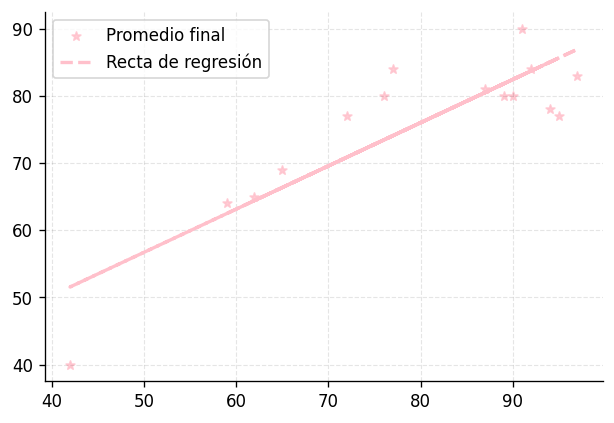

In [59]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="*",       # forma
    color='pink',     # color de los puntos
    edgecolor='pink',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='pink',   # color de la línea
    linewidth=2.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    '',
    fontsize=12
)

plt.ylabel(
    '',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="black"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [60]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,6.441997,42.611646
promedio_de_examenes_cortos,0.419219,0.867141


# **9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.901827735700704


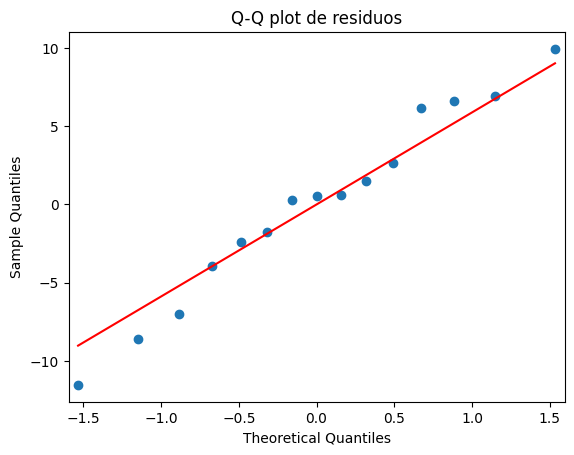

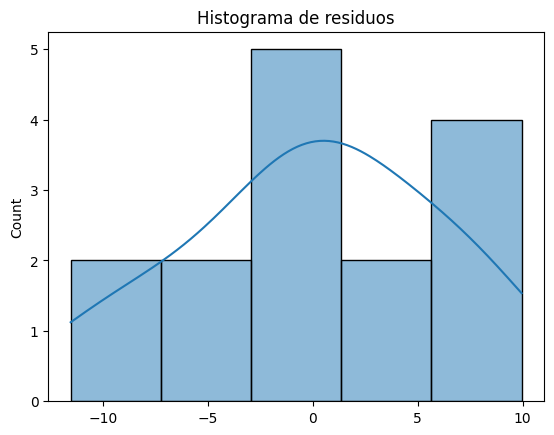

In [61]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación de resultados: Según el modelo, establece que si p es > a 0.5 los residuos siguen una distribución normal.**

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión.**

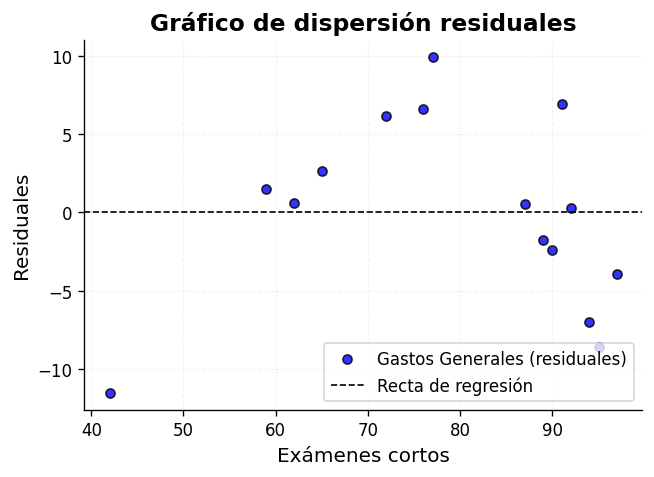

In [62]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos Generales (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Gráfico de dispersión residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Comente, ¿Parece que se verifican los supuestos? Para saber si cumplen con los requisitos necesarios para determinar un modelo.**

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [63]:
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2289



**Interpretación de resultados: Según el modelo, si el valor p menor que < 0.5, significa que no hay evidencia de heterocedasticidad.**

# **11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?**


In [64]:
modelo.predict([1, 70])

array([69.54941193])

In [65]:
modelo.predict([1, 75])

array([72.76531124])

In [66]:
modelo.predict([1, 84])

array([78.55393001])

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [67]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('promedio_final ~ promedio_de_examenes_cortos', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_de_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


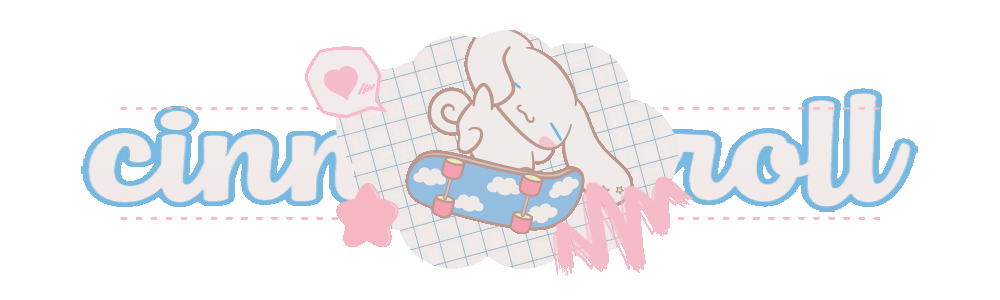

### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

# **1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).**

In [68]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/Yunuenn/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_02.csv"
df = pd.read_csv(link_csv)
df

,categoria_salario,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


In [69]:
x = df ['ausencias']
y = df ['categoria_salario']

# **2.   Realice un diagrama de dispersión para estos datos.**

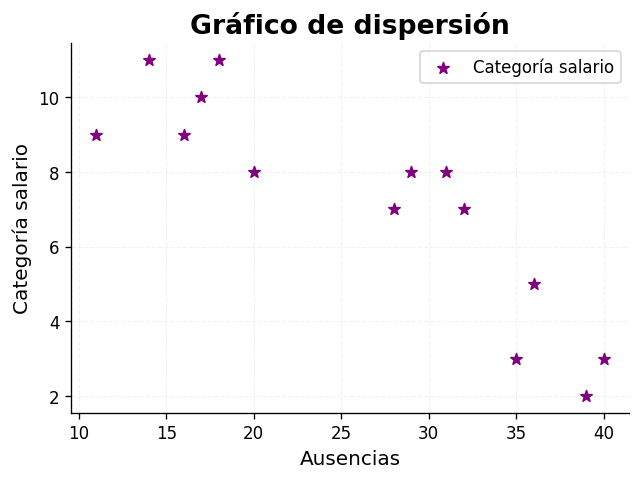

In [70]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="*",       # forma
    color='purple',     # color de los puntos
    edgecolor='purple',    # borde de los puntos
    alpha=1,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Categoría salario' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoría salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

 **3. ¿Los datos soportan la suposición de linealidad?**


# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [71]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
Valor p:  0.0000


**Interpretación de resultados:**

In [72]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,14.058843
ausencias,-0.261814


# **5. Calcule el coeficiente de determinación e interprete el resultado.**

In [73]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  77.46%



# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

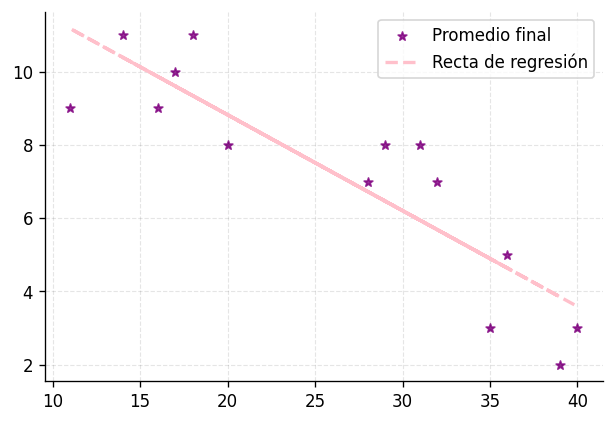

In [74]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="*",       # forma
    color='purple',     # color de los puntos
    edgecolor='purple',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='pink',   # color de la línea
    linewidth=2.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    '',
    fontsize=12
)

plt.ylabel(
    '',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="black"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [75]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,11.587445,16.530241
ausencias,-0.350638,-0.172989


# **9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.4172971767713699


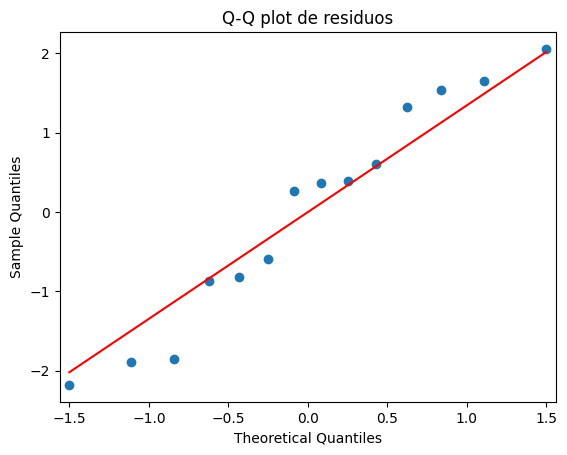

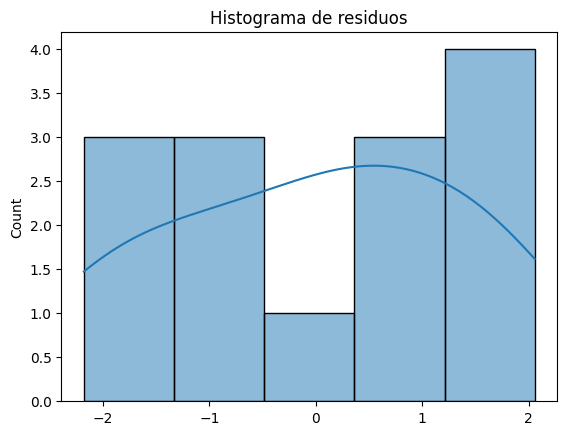

In [76]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión.**

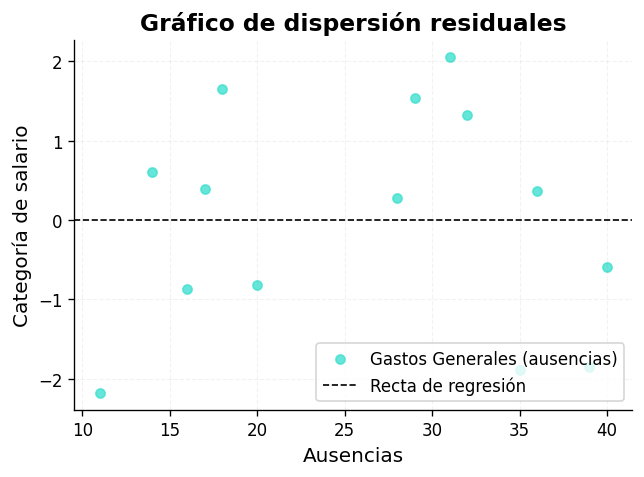

In [77]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='turquoise',     # color de los puntos
    edgecolor='turquoise',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos Generales (ausencias)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Gráfico de dispersión residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoría de salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

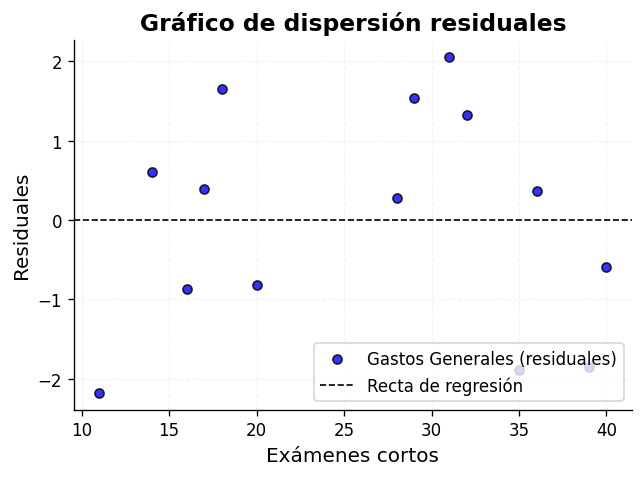

In [78]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos Generales (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Gráfico de dispersión residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [79]:
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.8955



# **11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [80]:
modelo.predict([1, 10])

array([11.44070657])

In [81]:
modelo.predict([1, 40])

array([3.58629613])

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [82]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('ausencias ~ categoria_salario', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
categoria_salario,1.0,983.548996,983.548996,41.243954,0.000033
Residual,12.0,286.165289,23.847107,NaN,NaN
